<a href="https://colab.research.google.com/github/jmdharshana/-CodeClause-Data-Science/blob/main/CYSP_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Jute Lentil Mothgram Coffee

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
import lightgbm as lgb

In [ ]:
cropDf = pd.read_csv("drive/MyDrive/Major Project/Datasets/Crop_recommendation-1.csv")
yieldDf = pd.read_excel("drive/MyDrive/Major Project/Datasets/cropYieldDataset.xlsx")
priceDf = pd.read_excel("drive/MyDrive/Major Project/Datasets/PricePredictionDatasetFinal.xlsx")

In [ ]:
cropDf = cropDf.drop(['Unnamed: 8','Unnamed: 9'],axis=1)
yieldDf = yieldDf.drop(['Fertilizer'],axis=1)
priceDf = priceDf.drop(['State','District','Market','Variety','Grade','Commodity_Code'],axis=1)

<h1>Sanity Check</h1>

<h3>Shape of Datasets</h3>

In [ ]:
print("Shape of Crop Prediction Dataset")
print(cropDf.shape)

print("Shape of Yield Prediction Dataset")
print(yieldDf.shape)

print("Shape of Price Prediction Dataset")
print(priceDf.shape)

Shape of Crop Prediction Dataset
(2200, 8)
Shape of Yield Prediction Dataset
(109, 6)
Shape of Price Prediction Dataset
(130611, 5)


<h3>Head of Datasets</h3>

In [ ]:
print("Head of Crop Prediction Dataset")
cropDf.head()

Head of Crop Prediction Dataset


,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:
print("Head of Yield Prediction Dataset")
yieldDf.head()

Head of Yield Prediction Dataset


,Rain Fall (mm),Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,28,80.0,24.0,20.0,12.0
1,480.0,36,70.0,20.0,18.0,8.0
2,1250.0,29,78.0,22.0,19.0,11.0
3,450.0,35,70.0,19.0,18.0,9.0
4,1200.0,27,79.0,22.0,19.0,11.0


In [ ]:
print("Head of Price Prediction Dataset")
priceDf.head()

Head of Price Prediction Dataset


,Commodity,Arrival_Date,Min_Price,Max_Price,Modal_Price
0,banana,19/07/2024,4600,5000.0,5000.0
1,banana,23/07/2024,4000,4400.0,4400.0
2,maize,27/07/2024,1800,2000.0,2000.0
3,coconut,18/07/2024,4000,4400.0,4400.0
4,coconut,22/07/2024,3500,3800.0,3800.0


<h3>Tail of Datasets</h3>

In [ ]:
print("Tail of Crop Prediction Dataset")
cropDf.tail()

Tail of Crop Prediction Dataset


,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [ ]:
print("Tail of Yield Prediction Dataset")
yieldDf.tail()

Tail of Yield Prediction Dataset


,Rain Fall (mm),Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
104,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN
107,NaN,NaN,NaN,NaN,NaN,NaN
108,NaN,:,NaN,NaN,NaN,NaN


In [ ]:
print("Tail of Price Prediction Dataset")
priceDf.tail()

Tail of Price Prediction Dataset


,Commodity,Arrival_Date,Min_Price,Max_Price,Modal_Price
130606,pigeonpeas,18/12/2024,7000,8000.0,8000.0
130607,pigeonpeas,19/12/2024,6000,7000.0,7000.0
130608,pigeonpeas,21/12/2024,6000,7000.0,7000.0
130609,pigeonpeas,23/12/2024,7500,8000.0,8000.0
130610,pigeonpeas,27/12/2024,7500,8000.0,8000.0


<h3>Information of Datasets</h3>

In [ ]:
print("Information of Crop Prediction Dataset")
cropDf.info()

Information of Crop Prediction Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   phosphorus   2200 non-null   int64  
 2   potassium    2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [ ]:
print("Information of Yield Prediction Dataset")
yieldDf.info()

Information of Yield Prediction Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Temperatue      100 non-null    object 
 2   Nitrogen (N)    99 non-null     float64
 3   Phosphorus (P)  99 non-null     float64
 4   Potassium (K)   99 non-null     float64
 5   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(5), object(1)
memory usage: 5.2+ KB


In [ ]:
print("Information of Price Prediction Dataset")
priceDf.info()

Information of Price Prediction Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130611 entries, 0 to 130610
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Commodity     130611 non-null  object 
 1   Arrival_Date  130611 non-null  object 
 2   Min_Price     130611 non-null  int64  
 3   Max_Price     130611 non-null  float64
 4   Modal_Price   130611 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 5.0+ MB


<h3>Null count and percentage of Datasets</h3>

In [ ]:
print("NUll values count in Crop Prediction Dataset")
cropDf.isnull().sum()

NUll values count in Crop Prediction Dataset


,0
Nitrogen,0
phosphorus,0
potassium,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:
print("NUll values count in Yield Prediction Dataset")
yieldDf.isnull().sum()

NUll values count in Yield Prediction Dataset


,0
Rain Fall (mm),10
Temperatue,9
Nitrogen (N),10
Phosphorus (P),10
Potassium (K),10
Yeild (Q/acre),10


In [ ]:
print("NUll values count in Price Prediction Dataset")
priceDf.isnull().sum()

NUll values count in Price Prediction Dataset


,0
Commodity,0
Arrival_Date,0
Min_Price,0
Max_Price,0
Modal_Price,0


In [ ]:
print("Null values percentage in Crop Prediction Dataset")
(cropDf.isnull().sum()/cropDf.shape[0])*100

Null values percentage in Crop Prediction Dataset


,0
Nitrogen,0.0
phosphorus,0.0
potassium,0.0
temperature,0.0
humidity,0.0
ph,0.0
rainfall,0.0
label,0.0


In [ ]:
print("Null values percentage in Yield Prediction Dataset")
(yieldDf.isnull().sum()/yieldDf.shape[0])*100

Null values percentage in Yield Prediction Dataset


,0
Rain Fall (mm),9.174312
Temperatue,8.256881
Nitrogen (N),9.174312
Phosphorus (P),9.174312
Potassium (K),9.174312
Yeild (Q/acre),9.174312


In [ ]:
print("Null values percentage in Price Prediction Dataset")
(priceDf.isnull().sum()/priceDf.shape[0])*100

Null values percentage in Price Prediction Dataset


,0
Commodity,0.0
Arrival_Date,0.0
Min_Price,0.0
Max_Price,0.0
Modal_Price,0.0


<h3>Duplicate count and percentage of datasets</h3>

In [ ]:
print("Duplicate value count and percentage of Crop Prediction dataset")
print(cropDf.duplicated().sum())
print((cropDf.duplicated().sum()/cropDf.shape[0])*100)

Duplicate value count and percentage of Crop Prediction dataset
0
0.0


In [ ]:
print("Duplicate value count and percentage of Yield Prediction dataset")
print(yieldDf.duplicated().sum())
print((yieldDf.duplicated().sum()/yieldDf.shape[0])*100)

Duplicate value count and percentage of Yield Prediction dataset
13
11.926605504587156


In [ ]:
print("Duplicate value count and percentage of Price Prediction dataset")
print(priceDf.duplicated().sum())
print((priceDf.duplicated().sum()/priceDf.shape[0])*100)

Duplicate value count and percentage of Price Prediction dataset
30987
23.724648000551255


<h3>Garbage values of Datasets</h3>

In [ ]:
print("Garbage values in Crop Prediction Dataset")

for i in cropDf.select_dtypes(include="object").columns:
  print(cropDf[i].value_counts())
  print(cropDf[i].value_counts()[0])
  print("-"*50)

Garbage values in Crop Prediction Dataset
label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64
100
--------------------------------------------------


<ipython-input-25-05d9201b2236>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(cropDf[i].value_counts()[0])


In [ ]:
print("Garbage values in Price Prediction Dataset")

for i in priceDf.select_dtypes(include="object").columns:
  print(priceDf[i].value_counts())
  print(priceDf[i].value_counts()[0])
  print("-"*50)

Garbage values in Price Prediction Dataset
Commodity
coconut        38306
rice           28095
cotton         14223
banana         13446
maize           9748
papaya          9225
pomegranate     3414
apple           3168
orange          2955
grapes          2672
watermelon      1936
mango           1822
muskmelon       1191
pigeonpeas       354
kidneybeans       41
blackgram          7
chickpea           6
mungbean           2
Name: count, dtype: int64
38306
--------------------------------------------------
Arrival_Date
16/07/2024    451
31/07/2024    339
24/07/2024    339
23/07/2024    338
18/07/2024    336
             ... 
16/06/2024      2
31/12/2023      2
16/04/2023      2
26/11/2023      2
15/01/2024      2
Name: count, Length: 2188, dtype: int64
451
--------------------------------------------------


<ipython-input-26-18aaa8bd6826>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(priceDf[i].value_counts()[0])
<ipython-input-26-18aaa8bd6826>:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(priceDf[i].value_counts()[0])


<h1>Exploratory Data Analysis for Crop Prediction Dataset</h1>

<h3>Descriptin of Dataset</h3>

In [ ]:
cropDf.describe()

,Nitrogen,phosphorus,potassium,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
cropDf.describe(include="object")

,label
count,2200
unique,22
top,rice
freq,100


<h3>Distribution of Dataset</h3>

Text(0.5, 1.0, 'Distribution of Different Crops in the Dataset')

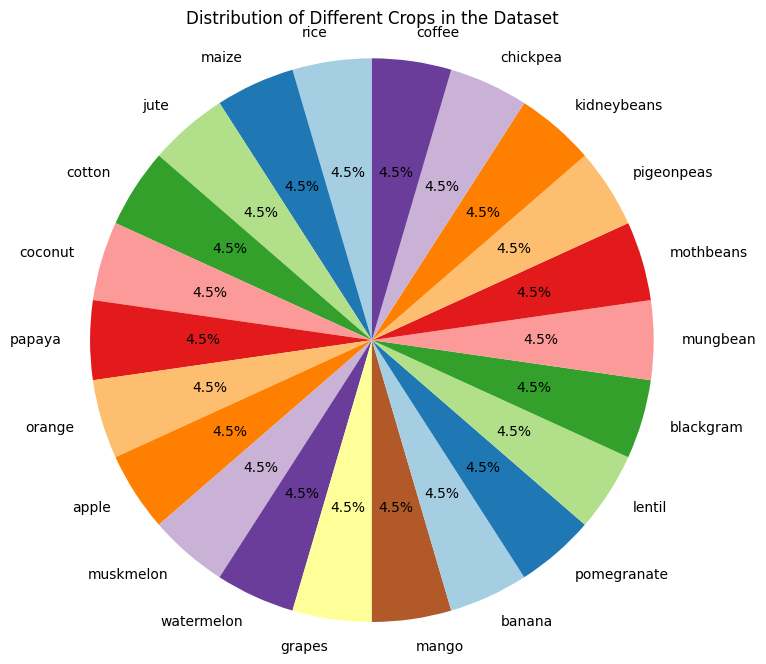

In [ ]:
crop_counts = cropDf['label'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8,8))
plt.pie(crop_counts, labels=crop_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

# Adding a title
plt.title("Distribution of Different Crops in the Dataset")

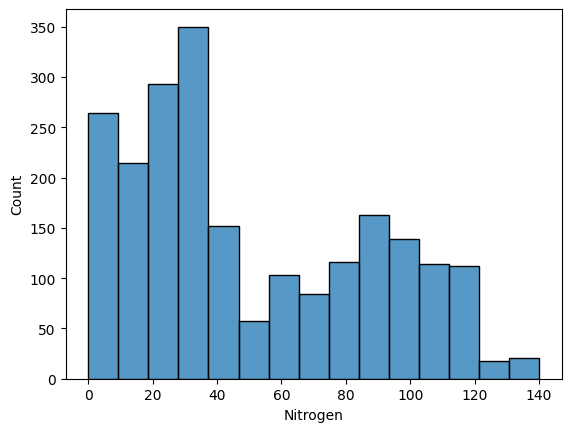

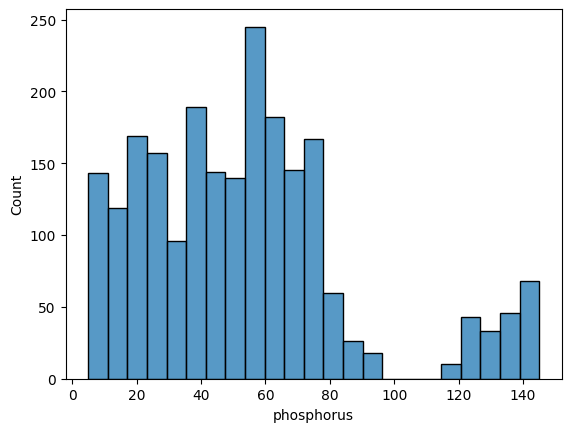

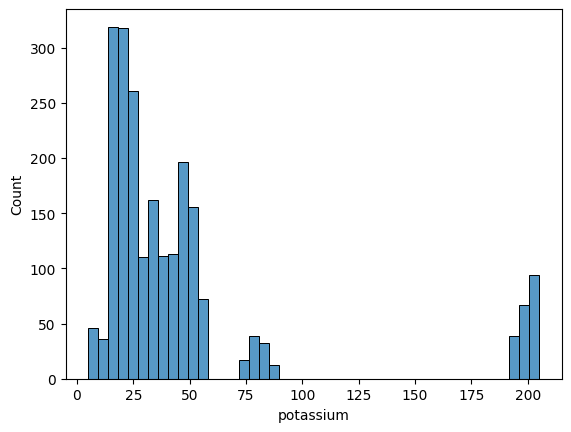

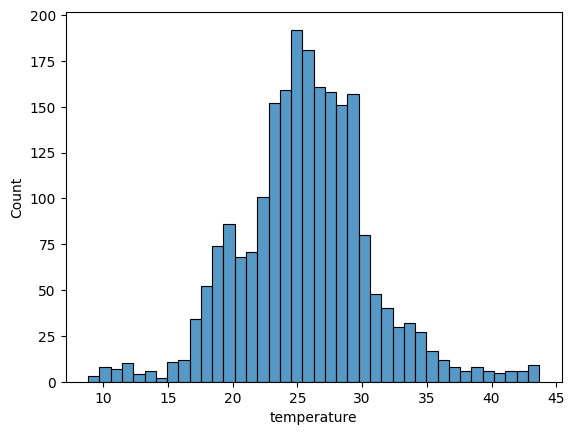

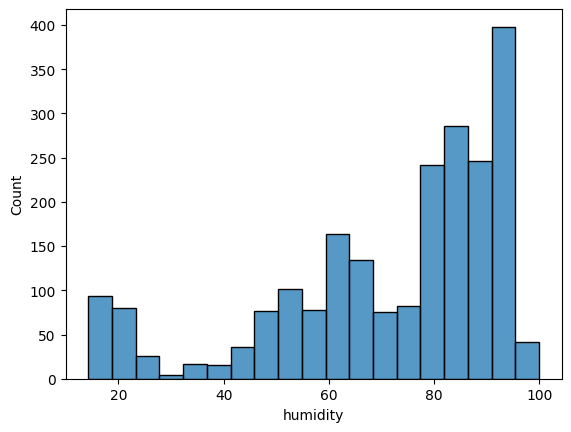

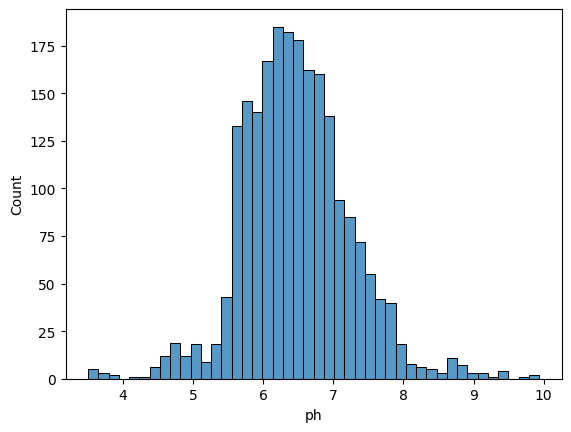

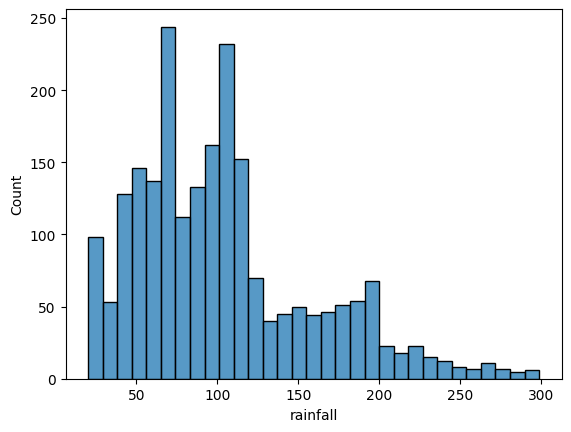

In [ ]:
for i in cropDf.select_dtypes(include="number").columns:
  sns.histplot(data=cropDf,x=i)
  plt.show()

<h3>Outliers of Dataset</h3>

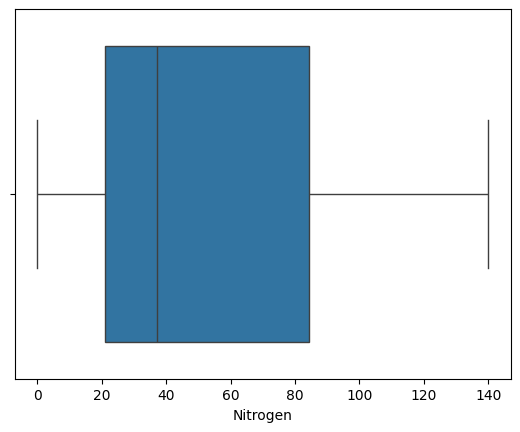

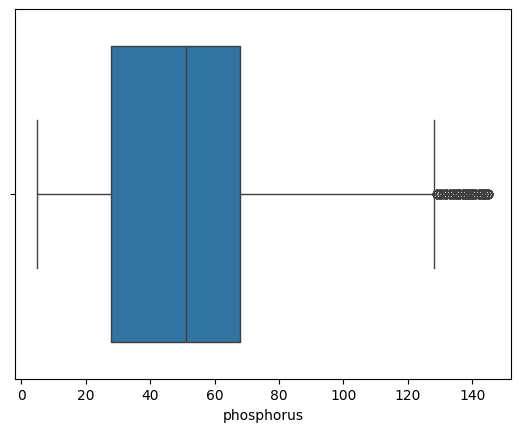

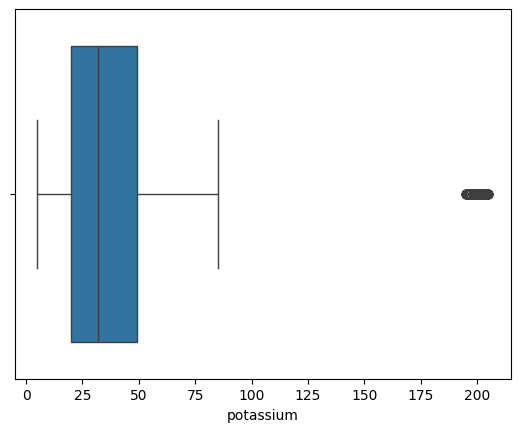

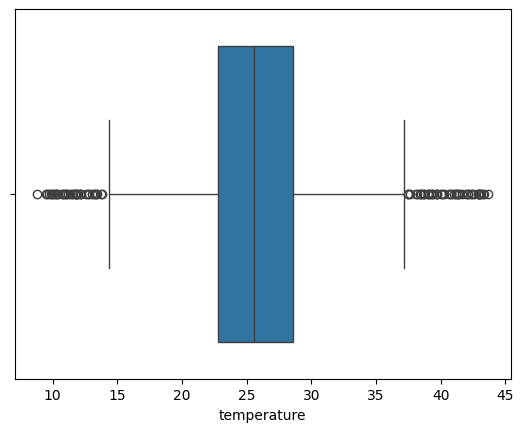

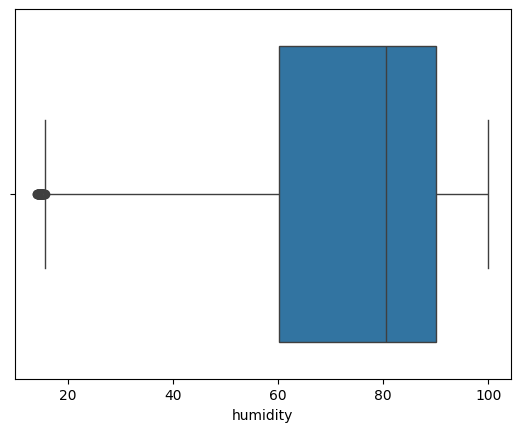

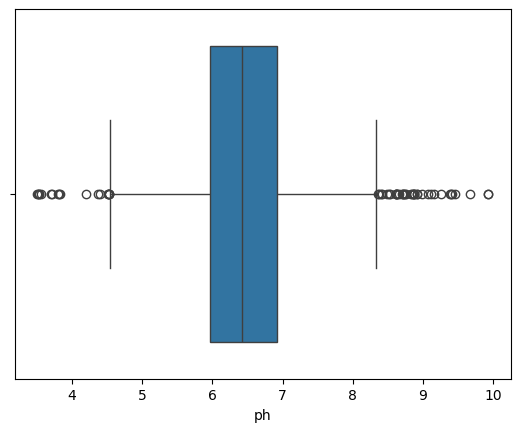

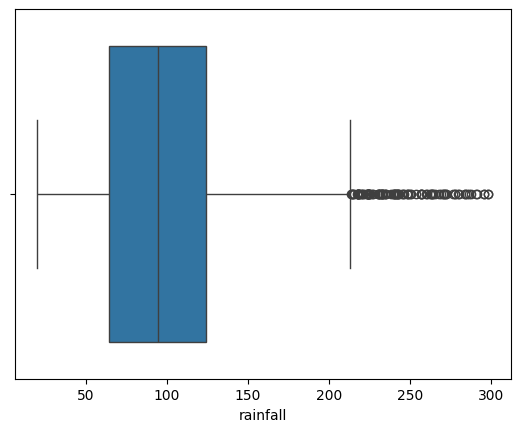

In [ ]:
for i in cropDf.select_dtypes(include="number").columns:
  sns.boxplot(data=cropDf,x=i)
  plt.show()

In [ ]:
cropDf.select_dtypes(include="number").columns

Index(['Nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph',
       'rainfall'],
      dtype='object')

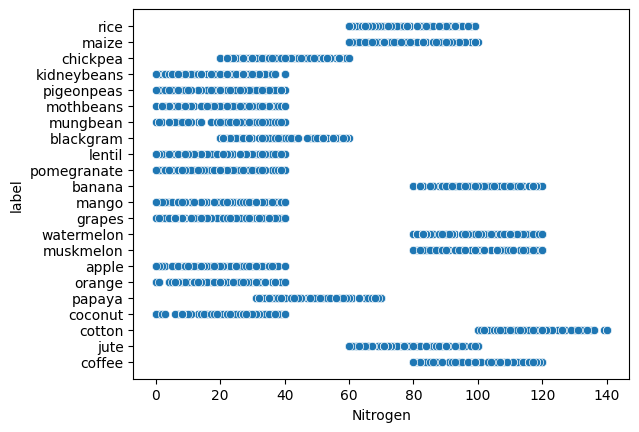

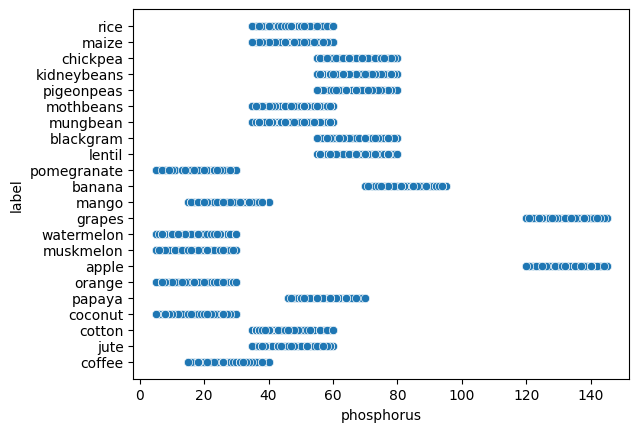

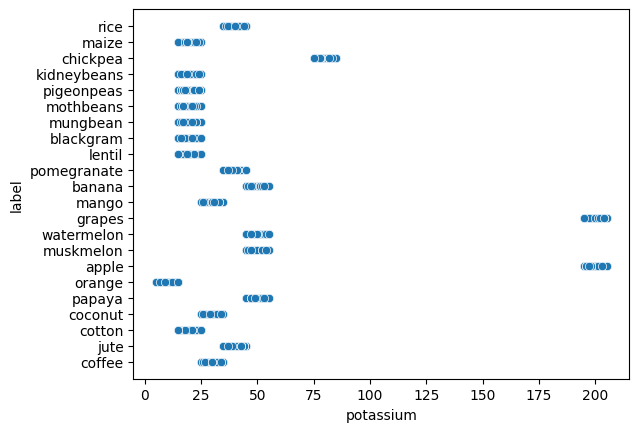

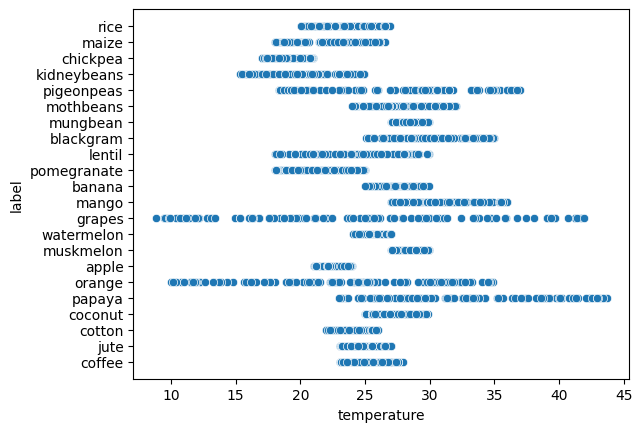

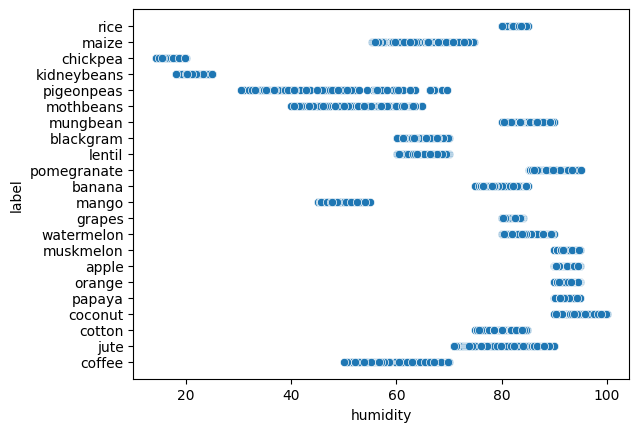

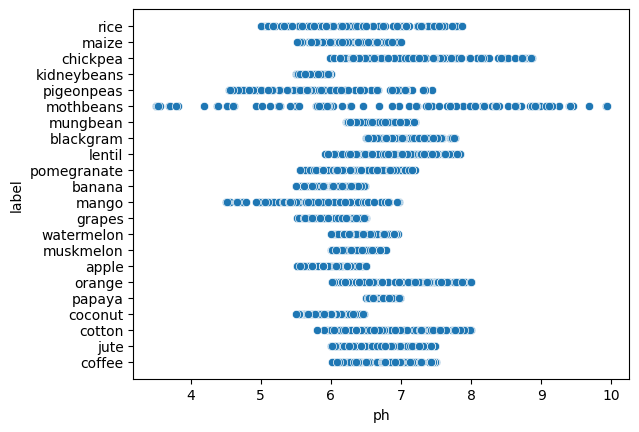

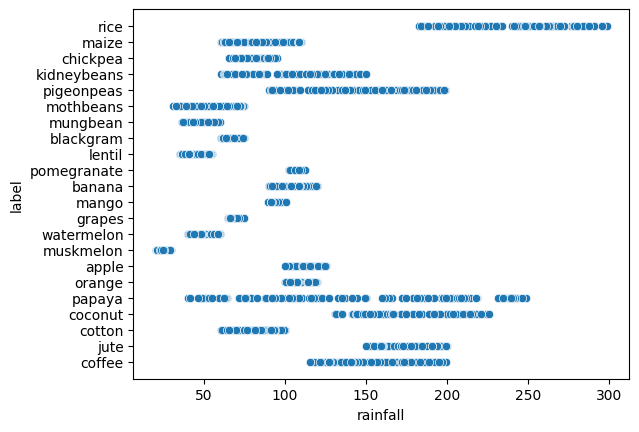

In [ ]:
for i in ['Nitrogen', 'phosphorus', 'potassium', 'temperature', 'humidity', 'ph',
       'rainfall']:
       sns.scatterplot(data=cropDf,x=i,y="label")
       plt.show()

<Axes: >

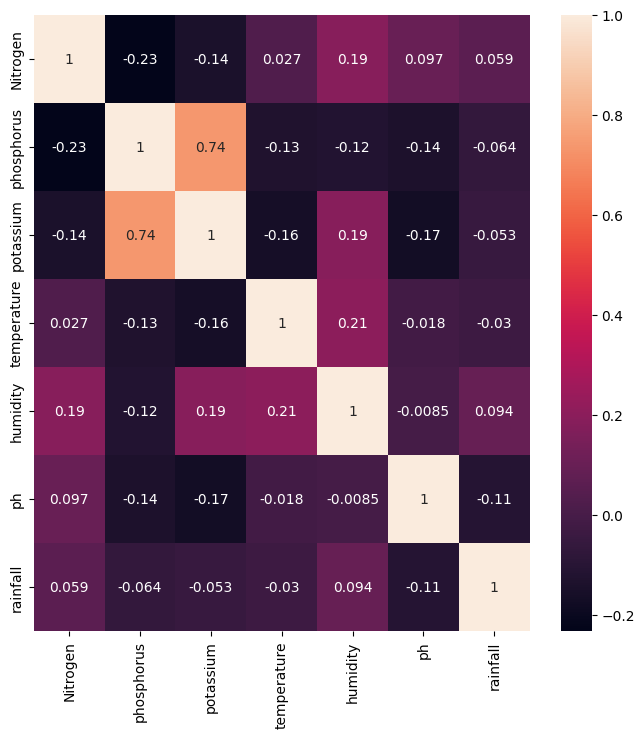

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(cropDf.select_dtypes(include="number").corr(), annot=True)

In [ ]:
sns.pairplot(cropDf,vars=['Nitrogen','phosphorus','potassium','temperature','humidity','ph','rainfall','label'])
plt.figure(figsize=(200000,200000))
plt.show()

<h1>Exploratory Data Analysis for Price Prediction Dataset</h1>

<h3>Description of Dataset</h3>

In [ ]:
priceDf.describe()

In [ ]:
priceDf.describe(include="object")

<h3>Distribution of Dataset</h3>

In [ ]:
crop_counts = priceDf['Commodity'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(12,12))
plt.pie(crop_counts, labels=crop_counts.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

plt.legend()

# Adding a title
plt.title("Distribution of Different Crops in the Dataset")

In [ ]:
for i in priceDf.select_dtypes(include="number").columns:
  sns.histplot(data=priceDf,x=i)
  plt.show()

<h3>Outlier analysis of Dataset</h3>

In [ ]:
for i in priceDf.select_dtypes(include="number").columns:
  sns.boxplot(data=priceDf,x=i)
  plt.show()

In [ ]:
priceDf.select_dtypes(include="number").columns

In [ ]:
for i in ['Min_Price', 'Max_Price', 'Modal_Price']:
       sns.scatterplot(data=priceDf,x=i,y="Commodity")
       plt.show()

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(priceDf.select_dtypes(include="number").corr(), annot=True)

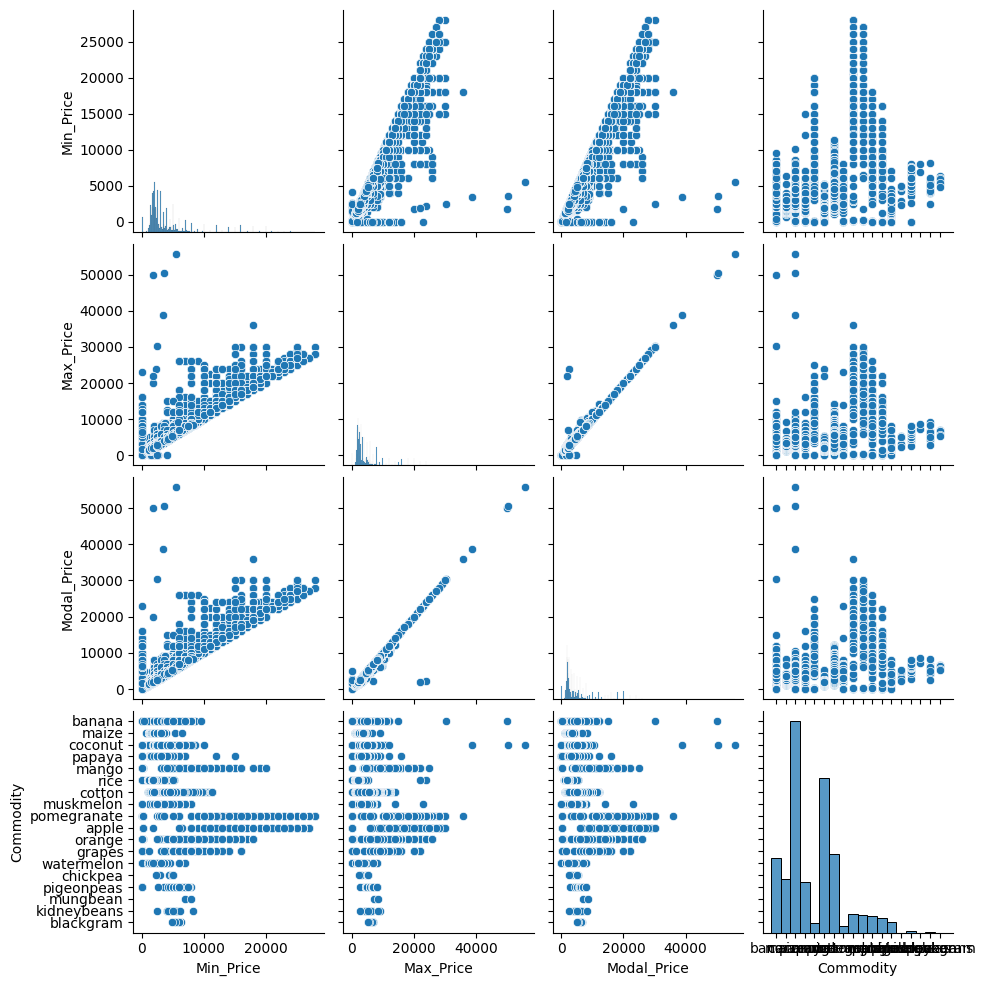

<Figure size 2e+07x2e+07 with 0 Axes>

In [ ]:
sns.pairplot(priceDf,vars=['Min_Price', 'Max_Price', 'Modal_Price','Commodity'])
plt.figure(figsize=(200000,200000))
plt.show()

<h1>Exploratory Data Analysis of Yield Dataset</h1>

<h3>Description of Dataset</h3>

In [ ]:
yieldDf.describe()

,Rain Fall (mm),Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,849.797980,70.737374,21.131313,18.060606,9.050505
std,400.042676,6.677079,1.951695,1.817254,1.965902
min,400.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,65.000000,19.500000,16.000000,7.000000
50%,1150.000000,71.000000,21.000000,19.000000,9.000000
75%,1237.500000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,25.000000,22.000000,12.000000


<h3>Data distribution of Dataset</h3>

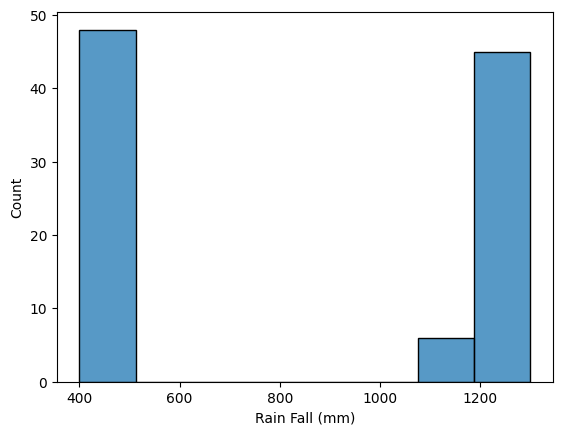

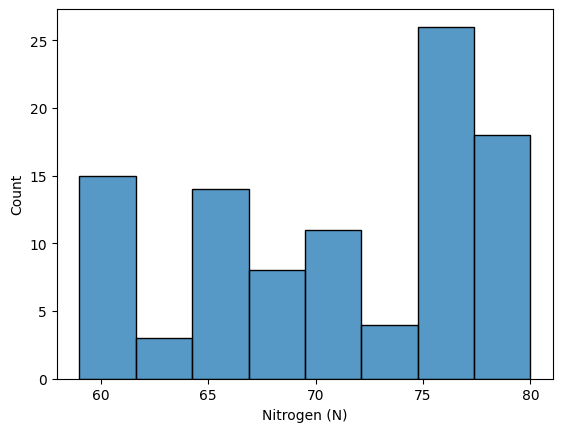

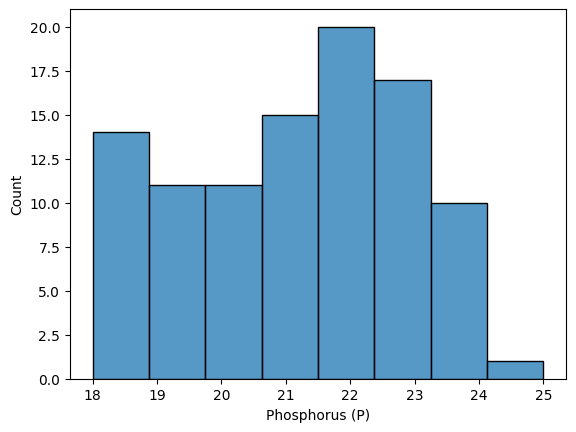

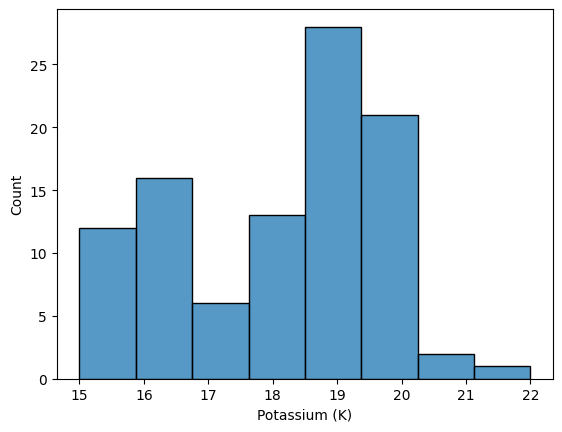

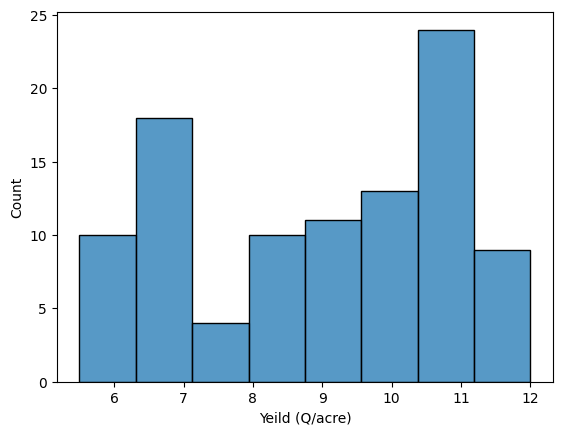

In [ ]:
for i in yieldDf.select_dtypes(include="number").columns:
  sns.histplot(data=yieldDf,x=i)
  plt.show()

<h3>Outlier analysis of Dataset</h3>

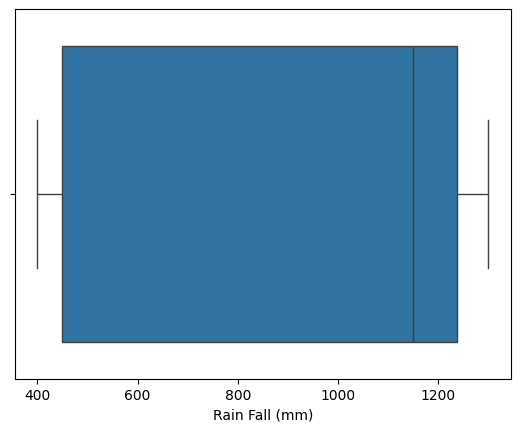

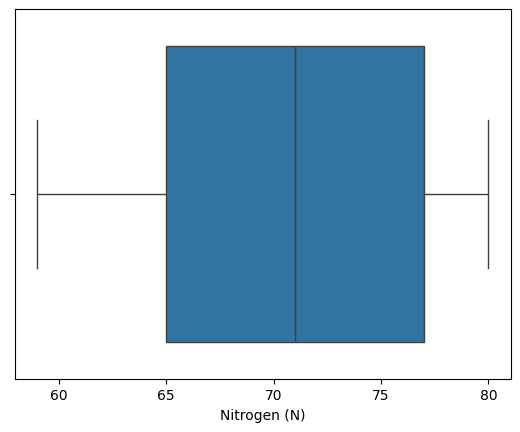

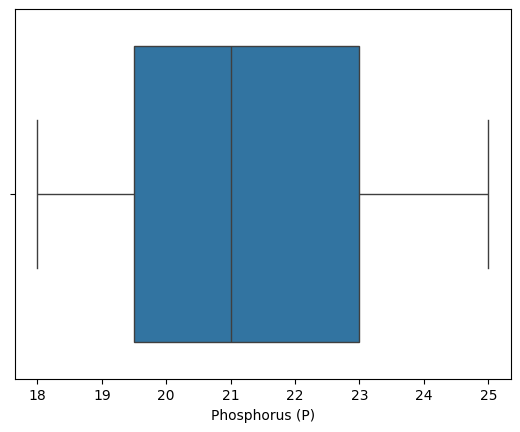

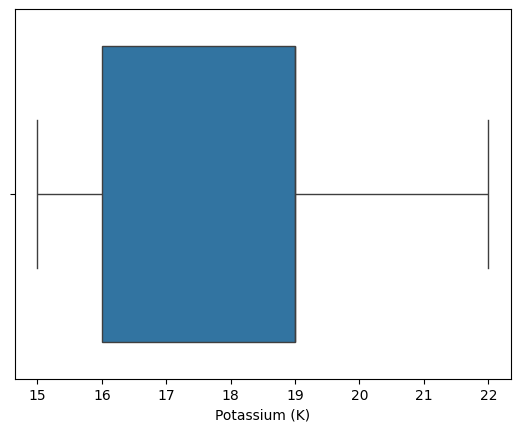

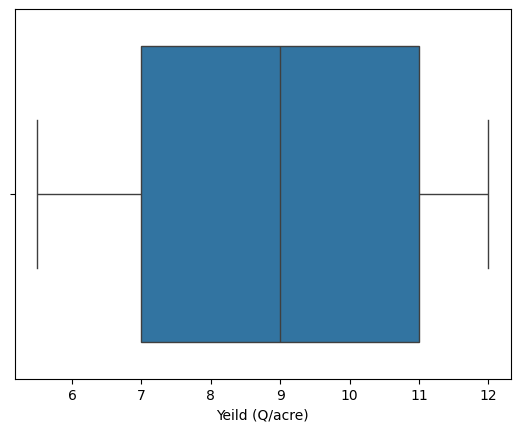

In [ ]:
for i in yieldDf.select_dtypes(include="number").columns:
  sns.boxplot(data=yieldDf,x=i)
  plt.show()

In [ ]:
yieldDf.select_dtypes(include="number").columns

Index(['Rain Fall (mm)', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
       'Yeild (Q/acre)'],
      dtype='object')

<Axes: >

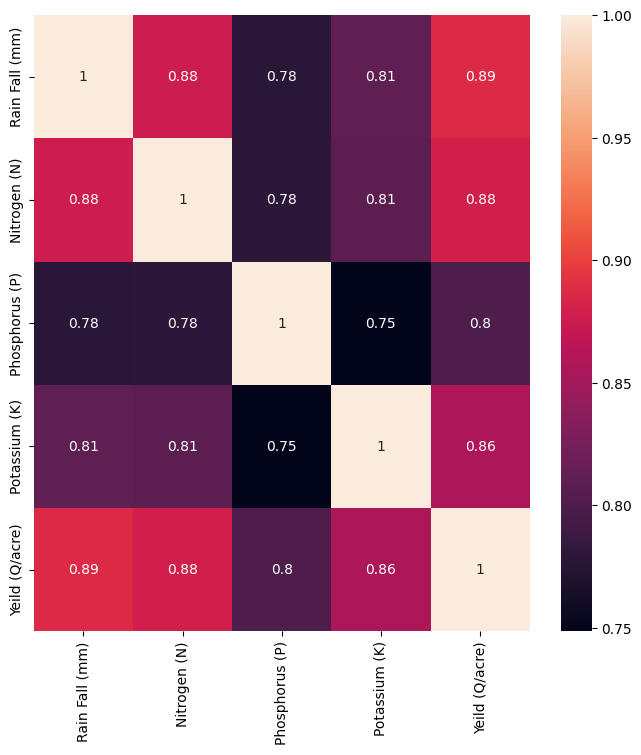

In [ ]:
plt.figure(figsize=(8,8))
sns.heatmap(yieldDf.select_dtypes(include="number").corr(), annot=True)

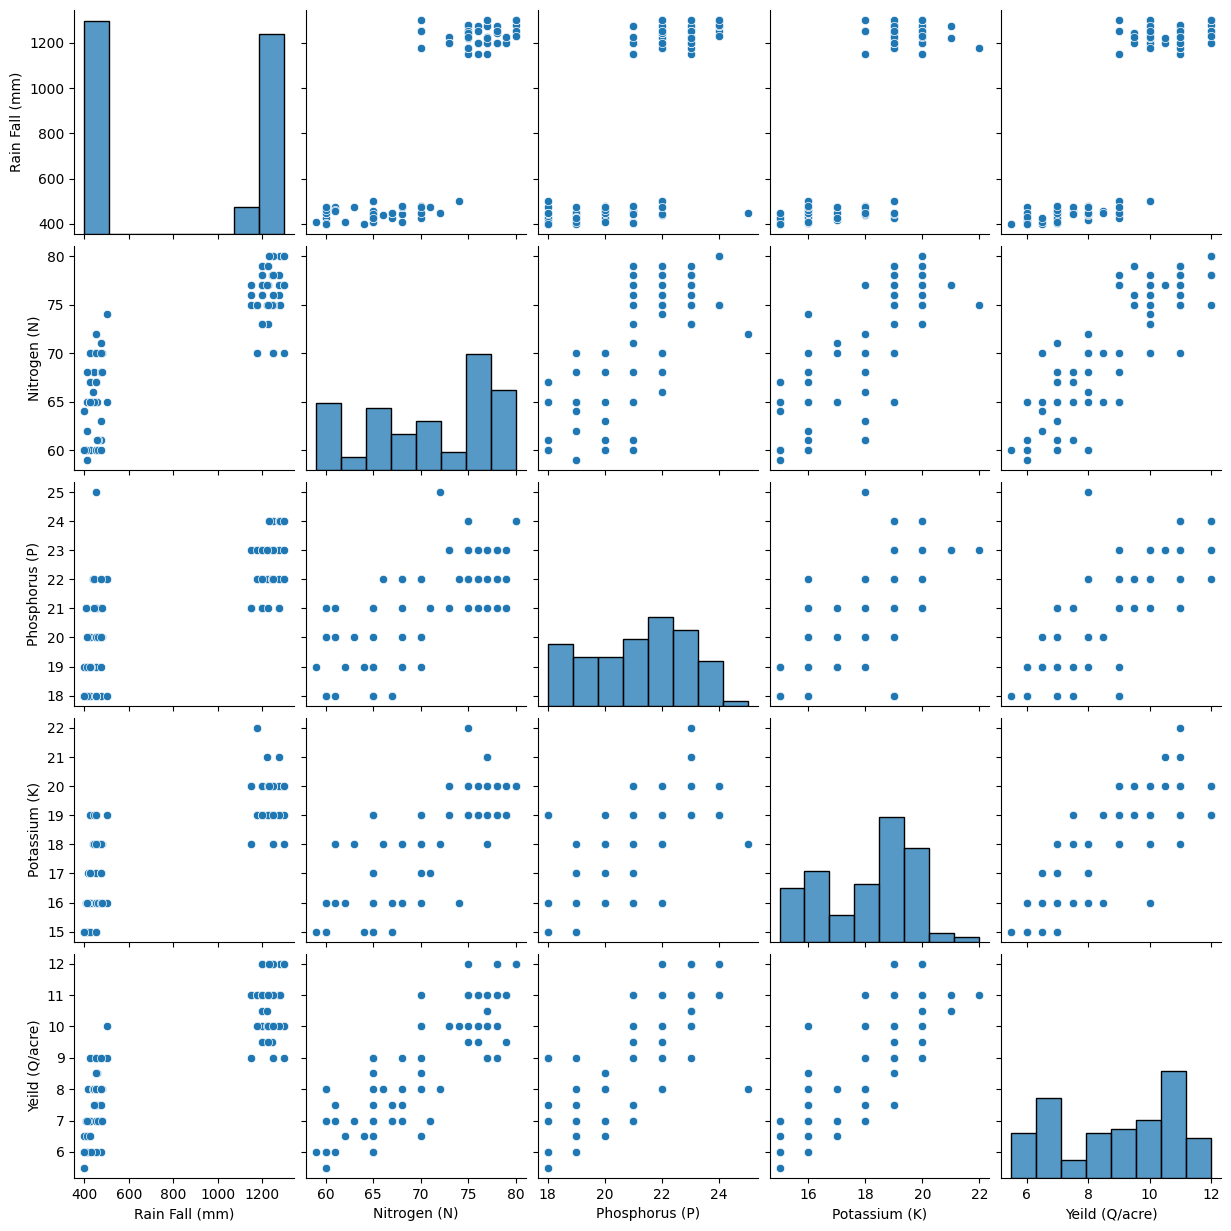

<Figure size 2e+07x2e+07 with 0 Axes>

In [ ]:
sns.pairplot(yieldDf,vars=['Rain Fall (mm)', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
       'Yeild (Q/acre)'])
plt.figure(figsize=(200000,200000))
plt.show()

<h1>Outlier Removal from Crop Price Dataset</h1>

In [ ]:
def wisker(columnName,column):
  q1,q3 = np.percentile(column,[25,75])
  iqr = q3-q1
  lwb = q1 - (1.5*iqr)
  upb = q3 + (1.5*iqr)
  print("ColumnName: ",columnName,", Lower Bound: ",lwb,", Upper Bound: ",upb)
  return lwb,upb

In [ ]:
priceDf_outlier_removed = priceDf.copy()
for i in ['Min_Price', 'Max_Price', 'Modal_Price']:
  lwb,upb = wisker(i,priceDf_outlier_removed[i])
  priceDf_outlier_removed = priceDf_outlier_removed[ (priceDf_outlier_removed[i] >= lwb) & (priceDf_outlier_removed[i] <= upb) ]
  print(priceDf_outlier_removed.shape)
  #df_outlier_removed.drop(indexAge , inplace=True)
  # df_outlier_removed[i] = np.where(df_outlier_removed[i]<lwb,lwb,df_outlier_removed[i])
  # df_outlier_removed[i] = np.where(df_outlier_removed[i]>upb,upb,df_outlier_removed[i])

ColumnName:  Min_Price , Lower Bound:  -2125.0 , Upper Bound:  8475.0
(120996, 5)
ColumnName:  Max_Price , Lower Bound:  -2100.0 , Upper Bound:  8860.0
(118862, 5)
ColumnName:  Modal_Price , Lower Bound:  -1825.0 , Upper Bound:  8215.0
(118240, 5)


In [ ]:
priceDf_outlier_removed

,Commodity,Arrival_Date,Min_Price,Max_Price,Modal_Price
0,banana,19/07/2024,4600,5000.0,5000.0
1,banana,23/07/2024,4000,4400.0,4400.0
2,maize,27/07/2024,1800,2000.0,2000.0
3,coconut,18/07/2024,4000,4400.0,4400.0
4,coconut,22/07/2024,3500,3800.0,3800.0
...,...,...,...,...,...
130606,pigeonpeas,18/12/2024,7000,8000.0,8000.0
130607,pigeonpeas,19/12/2024,6000,7000.0,7000.0
130608,pigeonpeas,21/12/2024,6000,7000.0,7000.0
130609,pigeonpeas,23/12/2024,7500,8000.0,8000.0


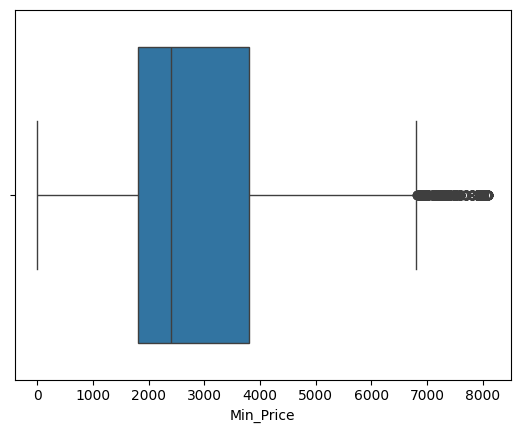

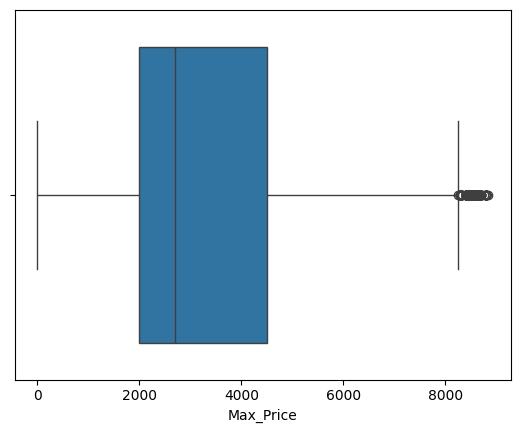

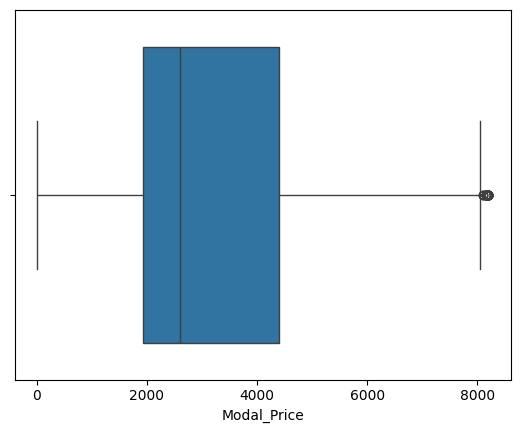

In [ ]:
for i in priceDf_outlier_removed.select_dtypes(include="number").columns:
  sns.boxplot(data=priceDf_outlier_removed,x=i)
  plt.show()

<h1>Null values removal from Crop Yield dataset</h1>

In [ ]:
yieldDf_null_removed = yieldDf.copy()
yieldDf_null_removed = yieldDf_null_removed.dropna()

<h1>Outlier Removal from Crop Yield dataset</h1>

In [ ]:
print(yieldDf.shape)
yieldDf_outlier_removed = yieldDf_null_removed.copy()
for i in ['Rain Fall (mm)', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
       'Yeild (Q/acre)']:
  lwb,upb = wisker(i,yieldDf_outlier_removed[i])
  yieldDf_outlier_removed = yieldDf_outlier_removed[ (yieldDf_outlier_removed[i] >= lwb) & (yieldDf[i] <= upb) ]
  print(yieldDf_outlier_removed.shape)
  #df_outlier_removed.drop(indexAge , inplace=True)
  # df_outlier_removed[i] = np.where(df_outlier_removed[i]<lwb,lwb,df_outlier_removed[i])
  # df_outlier_removed[i] = np.where(df_outlier_removed[i]>upb,upb,df_outlier_removed[i])

(109, 6)
ColumnName:  Rain Fall (mm) , Lower Bound:  -731.25 , Upper Bound:  2418.75
(99, 6)
ColumnName:  Nitrogen (N) , Lower Bound:  47.0 , Upper Bound:  95.0
(99, 6)
ColumnName:  Phosphorus (P) , Lower Bound:  14.25 , Upper Bound:  28.25
(99, 6)
ColumnName:  Potassium (K) , Lower Bound:  11.5 , Upper Bound:  23.5
(99, 6)
ColumnName:  Yeild (Q/acre) , Lower Bound:  1.0 , Upper Bound:  17.0
(99, 6)


<ipython-input-56-fd02aa56c2f8>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yieldDf_outlier_removed = yieldDf_outlier_removed[ (yieldDf_outlier_removed[i] >= lwb) & (yieldDf[i] <= upb) ]
<ipython-input-56-fd02aa56c2f8>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yieldDf_outlier_removed = yieldDf_outlier_removed[ (yieldDf_outlier_removed[i] >= lwb) & (yieldDf[i] <= upb) ]
<ipython-input-56-fd02aa56c2f8>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yieldDf_outlier_removed = yieldDf_outlier_removed[ (yieldDf_outlier_removed[i] >= lwb) & (yieldDf[i] <= upb) ]
<ipython-input-56-fd02aa56c2f8>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  yieldDf_outlier_removed = yieldDf_outlier_removed[ (yieldDf_outlier_removed[i] >= lwb) & (yieldDf[i] <= upb) ]
<ipython-input-56-fd02aa56c2f8>:6: UserWarning: Boolean Series key will be reindexed to match DataFrame 

In [ ]:
yieldDf_outlier_removed

,Rain Fall (mm),Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,28,80.0,24.0,20.0,12.0
1,480.0,36,70.0,20.0,18.0,8.0
2,1250.0,29,78.0,22.0,19.0,11.0
3,450.0,35,70.0,19.0,18.0,9.0
4,1200.0,27,79.0,22.0,19.0,11.0
...,...,...,...,...,...,...
94,1250.0,28,78.0,23.0,20.0,9.0
95,425.0,39,65.0,19.0,17.0,6.5
96,1220.0,28,77.0,23.0,21.0,10.5
97,480.0,36,68.0,21.0,16.0,7.0


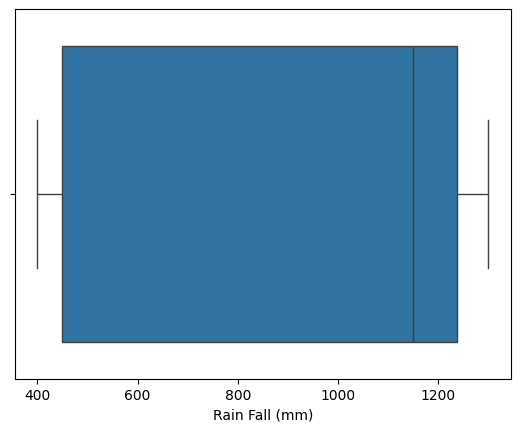

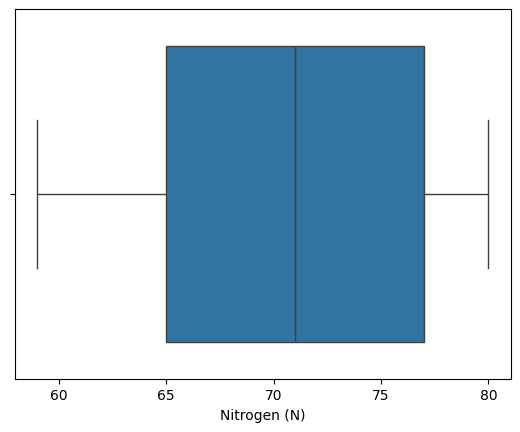

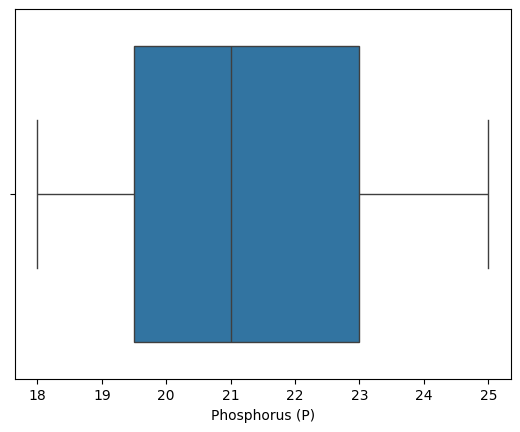

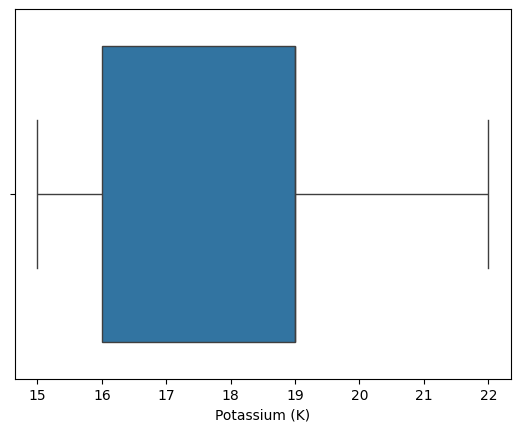

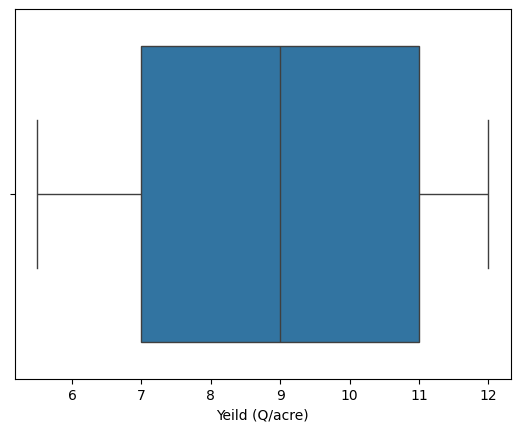

In [ ]:
for i in yieldDf_outlier_removed.select_dtypes(include="number").columns:
  sns.boxplot(data=yieldDf_outlier_removed,x=i)
  plt.show()

<h1>Augmentation of Crop Yield Dataset</h1>

In [ ]:
def augment_data(df, augmentation_factor=2, noise_level=0.1):

    augmented_data = []

    for index, row in df.iterrows():
        augmented_data.append(row.to_dict())  # Include the original row

        for _ in range(augmentation_factor):
            new_row = row.copy()

            for col in ['Rain Fall (mm)', 'Temperatue', 'Nitrogen (N)', 'Phosphorus (P)', 'Potassium (K)',
       'Yeild (Q/acre)']:
                if pd.api.types.is_numeric_dtype(new_row[col]): # Ensure it's numeric before adding noise.
                    noise = np.random.normal(0, noise_level * new_row[col])
                    new_row[col] += noise

            augmented_data.append(new_row.to_dict())

    return pd.DataFrame(augmented_data)

In [ ]:
yieldDf_augmented = augment_data(yieldDf_outlier_removed, augmentation_factor=10, noise_level=0.01) # Reduced noise for better results in this example.

In [ ]:
print(yieldDf_augmented.shape)
yieldDf_augmented.describe()

(1089, 6)


,Rain Fall (mm),Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000,1089.000000
mean,849.797980,32.393939,70.737374,21.131313,18.060606,9.050505
std,398.200001,5.401355,6.646323,1.942705,1.808883,1.956847
min,400.000000,24.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,28.000000,65.000000,19.000000,16.000000,7.000000
50%,1150.000000,29.000000,71.000000,21.000000,19.000000,9.000000
75%,1245.000000,38.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,40.000000,80.000000,25.000000,22.000000,12.000000


In [ ]:
yieldDf_augmented.head()

,Rain Fall (mm),Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,28,80.0,24.0,20.0,12.0
1,1230.0,28,80.0,24.0,20.0,12.0
2,1230.0,28,80.0,24.0,20.0,12.0
3,1230.0,28,80.0,24.0,20.0,12.0
4,1230.0,28,80.0,24.0,20.0,12.0


In [ ]:
yieldDf_augmented.tail()

,Rain Fall (mm),Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
1084,1230.0,28,80.0,24.0,20.0,12.0
1085,1230.0,28,80.0,24.0,20.0,12.0
1086,1230.0,28,80.0,24.0,20.0,12.0
1087,1230.0,28,80.0,24.0,20.0,12.0
1088,1230.0,28,80.0,24.0,20.0,12.0


<h1>Training of Crop Prediction Model</h1>

<h3>Encoding the Crop Prediction Dataset</h3>

In [ ]:
cropDf_x = cropDf.iloc[:,0:7].values
cropDf_y = cropDf.iloc[:,7].values

In [ ]:
label_encoder = LabelEncoder()

cropDf_y_encoded = label_encoder.fit_transform(cropDf_y)

np.unique(cropDf_y_encoded)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21])

<h3>Splitting the Crop Prediction Dataset</h3>

In [ ]:
cropDf_x_train, cropDf_x_test, cropDf_y_train, cropDf_y_test = train_test_split(cropDf_x,cropDf_y_encoded,test_size=0.25,random_state=0)
print("Shape of training dataset with outliers", cropDf_x_train.shape)
print("Shape of testing dataset with outliers", cropDf_x_test.shape)

Shape of training dataset with outliers (1650, 7)
Shape of testing dataset with outliers (550, 7)


<h3>Model Training</h3>

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(cropDf_x_train, cropDf_y_train)

rf_y_pred = rf_model.predict(cropDf_x_test)

print("Training Accuracy: ",rf_model.score(cropDf_x_train, cropDf_y_train))
print("Testing Accuracy: ",rf_model.score(cropDf_x_test, cropDf_y_test))

print(cropDf_y_test[0:10],rf_y_pred[0:10])

Training Accuracy:  1.0
Testing Accuracy:  0.9981818181818182
[21 21  7  3  2 20 13  9 15  1] [21 21  7  3  2 20 13  9 15  1]


<h1>Training of Yield Prediction Model</h1>

<h3>Splitting the Yield Prediction Dataset</h3>

In [ ]:
yieldDf_x = yieldDf_augmented.iloc[:,0:5].values
yieldDf_y = yieldDf_augmented.iloc[:,5].values

In [ ]:
yieldDf_x_train, yieldDf_x_test, yieldDf_y_train, yieldDf_y_test = train_test_split(yieldDf_x,yieldDf_y,test_size=0.25,random_state=0)
print("Shape of training dataset with outliers", yieldDf_x_train.shape)
print("Shape of testing dataset with outliers", yieldDf_x_test.shape)

Shape of training dataset with outliers (816, 5)
Shape of testing dataset with outliers (273, 5)


<h3>Model Training</h3>

In [ ]:
xgb_model = XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(yieldDf_x_train, yieldDf_y_train)

xgb_y_pred = xgb_model.predict(yieldDf_x_test)

print("Training Accuracy: ",xgb_model.score(yieldDf_x_train, yieldDf_y_train))
print("Testing Accuracy: ",xgb_model.score(yieldDf_x_test, yieldDf_y_test))

print(yieldDf_y_test[0:10],xgb_y_pred[0:10])

Training Accuracy:  0.9980226377713525
Testing Accuracy:  0.9986780279627264
[ 7.  10.  10.  10.   6.   7.  11.   8.  10.  10.5] [ 7.0045223  9.996329  10.580427  10.002133   6.0010595  7.002759
 10.991262   7.990686   9.9991455 10.500225 ]


<h1>Training of Price Prediction Model</h1>

<h3>Splitting of Dataset</h3>

In [ ]:
priceDf_x = priceDf_outlier_removed.iloc[:,0:2].values
priceDf_y_max = priceDf_outlier_removed.iloc[:,2].values
priceDf_y_min = priceDf_outlier_removed.iloc[:,3].values
priceDf_y_mode = priceDf_outlier_removed.iloc[:,4].values

<h3>Model Training (Min Price)</h3>

In [ ]:
priceDf_x_train, priceDf_x_test, priceDf_y_train, priceDf_y_test = train_test_split(priceDf_x,priceDf_y_min,test_size=0.25,random_state=0)
print("Shape of training dataset", priceDf_x_train.shape)
print("Shape of testing dataset", priceDf_x_test.shape)

Shape of training dataset (88680, 2)
Shape of testing dataset (29560, 2)


In [ ]:
priceDf_outlier_removed_encoded = pd.get_dummies(priceDf_outlier_removed, columns=['Commodity'], drop_first=True)

features = [col for col in priceDf_outlier_removed_encoded.columns if col not in ['Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price']]
target = 'Min_Price'

train_data, test_data = train_test_split(priceDf_outlier_removed_encoded, test_size=0.25, shuffle=False, random_state=42)
X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

model = lgb.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_train, lgb_eval])

y_pred = model.predict(X_test, num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Min_Price): {rmse}")

RMSE (Min_Price): 1003.0346514128847


<h3>Model Training (Max Price)</h3>

In [ ]:
priceDf_x_train, priceDf_x_test, priceDf_y_train, priceDf_y_test = train_test_split(priceDf_x,priceDf_y_max,test_size=0.25,random_state=0)
print("Shape of training dataset", priceDf_x_train.shape)
print("Shape of testing dataset", priceDf_x_test.shape)

Shape of training dataset (88680, 2)
Shape of testing dataset (29560, 2)


In [ ]:
priceDf_outlier_removed_encoded = pd.get_dummies(priceDf_outlier_removed, columns=['Commodity'], drop_first=True)

features = [col for col in priceDf_outlier_removed_encoded.columns if col not in ['Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price']]
target = 'Max_Price'

train_data, test_data = train_test_split(priceDf_outlier_removed_encoded, test_size=0.25, shuffle=False, random_state=42)
X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

model = lgb.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_train, lgb_eval])

y_pred = model.predict(X_test, num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Max_Price): {rmse}")

RMSE (Max_Price): 1252.867515771773


<h3>Model Training (Modal Price)</h3>

In [ ]:
priceDf_x_train, priceDf_x_test, priceDf_y_train, priceDf_y_test = train_test_split(priceDf_x,priceDf_y_mode,test_size=0.25,random_state=0)
print("Shape of training dataset", priceDf_x_train.shape)
print("Shape of testing dataset", priceDf_x_test.shape)

Shape of training dataset (88680, 2)
Shape of testing dataset (29560, 2)


In [ ]:
priceDf_outlier_removed_encoded = pd.get_dummies(priceDf_outlier_removed, columns=['Commodity'], drop_first=True)

features = [col for col in priceDf_outlier_removed_encoded.columns if col not in ['Arrival_Date', 'Min_Price', 'Max_Price', 'Modal_Price']]
target = 'Modal_Price'

train_data, test_data = train_test_split(priceDf_outlier_removed_encoded, test_size=0.25, shuffle=False, random_state=42)
X_train, y_train = train_data[features], train_data[target]
X_test, y_test = test_data[features], test_data[target]

lgb_train = lgb.Dataset(X_train, y_train)
lgb_eval = lgb.Dataset(X_test, y_test, reference=lgb_train)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
}

model = lgb.train(params, lgb_train, num_boost_round=1000, valid_sets=[lgb_train, lgb_eval])

y_pred = model.predict(X_test, num_iteration=model.best_iteration)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Modal_Price): {rmse}")

RMSE (Modal_Price): 1271.4901842262668


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# ------------------ Load and Preprocess Data ------------------
df = pd.read_excel("drive/MyDrive/Major Project/Datasets/PricePredictionDatasetFinal.xlsx", parse_dates=["Arrival_Date"], index_col="Arrival_Date")
#df['Date'] = pd.to_datetime(df['Date'], format='ISO8601', errors='coerce')
df.index = pd.to_datetime(df.index, format='ISO8601', errors='coerce')

# Sorting by Date (important for time-series)
df = df.sort_index()

# Selecting relevant features
features = ['Commodity']  # Crop will be one-hot encoded
target_cols = ['Min_Price', 'Max_Price', 'Modal_Price']

# One-Hot Encode Crop Feature
df = pd.get_dummies(df, columns=['Commodity'])

# ------------------ Feature Engineering ------------------
def create_time_features(df):
    df["Year"] = df.index.year
    df["Month"] = df.index.month
    df["Week"] = df.index.isocalendar().week
    df["Day"] = df.index.day
    df["Day_of_Week"] = df.index.dayofweek
    return df

df = create_time_features(df)

# Function to create lag features for each target
def create_lag_features(df, target_cols, lags=[1, 3, 7, 14]):
    for target in target_cols:
        for lag in lags:
            df[f"{target}_lag_{lag}"] = df[target].shift(lag)
    return df

df = create_lag_features(df, target_cols)

# Create rolling window features
for target in target_cols:
    df[f"{target}_Rolling_Mean_7"] = df[target].rolling(window=7).mean()
    df[f"{target}_Rolling_Std_7"] = df[target].rolling(window=7).std()

# Drop NaN values created by shifting
df.dropna(inplace=True)

categorical_cols = ['Commodity']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# ------------------ Train-Test Split (Time-Based) ------------------
train_size = int(len(df) * 0.8)  # 80% Training, 20% Testing
train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop(columns=target_cols)
y_train = train[target_cols]
X_test = test.drop(columns=target_cols)
y_test = test[target_cols]

# ------------------ Train LightGBM Model for Each Price Type ------------------
models = {}
predictions = {}

for target in target_cols:
    print(f"Training LightGBM for {target}...")

    # Prepare LightGBM datasets
    lgb_train = lgb.Dataset(X_train, y_train[target], categorical_feature=categorical_cols)
    lgb_eval = lgb.Dataset(X_test, y_test[target], reference=lgb_train, reference=lgb_train, categorical_feature=categorical_cols)

    # Define Parameters
    params = {
      'objective': 'regression',
      'metric': 'rmse',
      'learning_rate': 0.1,
      'num_leaves': 31,
    }

    # Train Model
    model = lgb.train(params,lgb_train,valid_sets=[lgb_eval],  num_boost_round=100,callbacks=[lgb.early_stopping(10)])

    # Store Model
    models[target] = model

    # Predict on Test Set
    predictions[target] = model.predict(X_test)

    # Evaluate Performance
    rmse = np.sqrt(mean_squared_error(y_test[target], predictions[target]))
    print(f"RMSE for {target}: {rmse}\n")

# ------------------ Plot Actual vs Predicted Prices ------------------
plt.figure(figsize=(14, 6))
for target in target_cols:
    plt.plot(test.index, y_test[target], label=f"Actual {target}", linewidth=2)
    plt.plot(test.index, predictions[target], label=f"Predicted {target}", linestyle="dashed")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()


<ipython-input-78-59c9111301ee>:10: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_excel("drive/MyDrive/Major Project/Datasets/PricePredictionDatasetFinal.xlsx", parse_dates=["Arrival_Date"], index_col="Arrival_Date")


KeyError: 'Commodity'

In [ ]:
pip install --upgrade lightgbm